In [1]:
# STEP 00. Imports / Parameters
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import display

DATABASE_PATH = Path("healthcare.duckdb")
SOURCE_TABLE = "atc3_region_facil"
ATC_MASTER_TABLE = "atc_master"
START_DIAG_YM = 202001
END_DIAG_YM = 202212
START_YEAR = 2020
END_YEAR = 2022
ANALYSIS_MONTHS = 36
ANALYSIS_INSUP_TYPES = (4, 5, 7)

RECENCY_DECAY = 0.90
MAD_SCALE = 1.4826
GAP_THRESHOLD_PP = 10
GAP_Z_THRESHOLD = 3

DECLINE_TSTAT_THRESHOLD = 2
RECENT_YOY_MONTHS = 12
TOP_N_GROUPS = 12



plt.rcParams.update({
    "figure.figsize": (13, 7), "axes.grid": True,
    "axes.spines.top": False, "axes.spines.right": False,
})
pd.set_option("display.max_columns", 100)

analysis_definition = pd.DataFrame({
    "execution_order": [1, 2, 3, 4, 5],
    "checkpoint": [
        "ATC2 analysis source", "Matrix A axes", "Matrix A bubble", "Matrix B axes", "Decline warning",
    ],
    "definition": [
        "atc3_region_facil -> atcStep2Cd aggregation",
        "2022 Market Size x Structural Growth",
        "|Growth Amount| (sign shown separately)",
        "CGR x Structural Annual Growth",
        "Independent of Matrix A segment; structural growth + t-stat only",
    ],
})
print("Fixed analysis definition - verify before execution")
display(analysis_definition)


def robust_zscore(values: pd.Series) -> pd.Series:
    """Return median/MAD z-scores; use standard deviation only when MAD is zero."""
    values = pd.Series(values, dtype="float64")
    median = values.median()
    scale = MAD_SCALE * np.median(np.abs(values.dropna() - median))
    if not np.isfinite(scale) or scale == 0:
        std = values.std()
        return pd.Series(0.0, index=values.index) if not np.isfinite(std) or std == 0 else (values - values.mean()) / std
    return (values - median) / scale


def add_name_label(frame: pd.DataFrame) -> pd.Series:
    """Keep an ATC2 code visible if its master-name lookup is missing."""
    return frame["group_name"].fillna(frame["group_id"])


Fixed analysis definition - verify before execution


,execution_order,checkpoint,definition
0,1,ATC2 analysis source,atc3_region_facil -> atcStep2Cd aggregation
1,2,Matrix A axes,2022 Market Size x Structural Growth
2,3,Matrix A bubble,|Growth Amount| (sign shown separately)
3,4,Matrix B axes,CGR x Structural Annual Growth
4,5,Decline warning,Independent of Matrix A segment; structural gr...


In [6]:
# STEP 01. Source QA
con = duckdb.connect(str(DATABASE_PATH), read_only=True)
source_qa = con.execute(f"""
    SELECT
    COUNT(DISTINCT diagYm) AS month_count,
    COUNT(DISTINCT atcStep2Cd) AS atc2_count,
    COUNT(DISTINCT atcStep3Cd) AS atc3_count
FROM {SOURCE_TABLE}
WHERE CAST(diagYm AS INTEGER)
      BETWEEN {START_DIAG_YM} AND {END_DIAG_YM}
  AND CAST(insupTpCd AS INTEGER) IN (4,5,7);
""").df()
source_qa["is_exactly_36_months"] = source_qa["month_count"].eq(ANALYSIS_MONTHS)

atc2_month_coverage = con.execute(f"""
    SELECT
    atcStep2Cd,
    COUNT(DISTINCT diagYm) AS month_count
FROM {SOURCE_TABLE}
WHERE CAST(diagYm AS INTEGER)
      BETWEEN {START_DIAG_YM} AND {END_DIAG_YM}
  AND CAST(insupTpCd AS INTEGER) IN (4,5,7)
GROUP BY atcStep2Cd
ORDER BY month_count, atcStep2Cd;
    """).df()
atc2_month_coverage["is_exactly_36_months"] = atc2_month_coverage["month_count"].eq(ANALYSIS_MONTHS)



print("STEP 01 - source and period QA")
display(source_qa)
display(atc2_month_coverage[atc2_month_coverage['is_exactly_36_months']==True].atcStep2Cd.unique())
display(atc2_month_coverage[atc2_month_coverage['is_exactly_36_months']==False].atcStep2Cd.unique())
display(atc2_month_coverage[atc2_month_coverage['is_exactly_36_months']==False])
assert bool(source_qa.loc[0, "is_exactly_36_months"]), "Analysis window must contain exactly 36 distinct months."



STEP 01 - source and period QA


,month_count,atc2_count,atc3_count,is_exactly_36_months
0,36,78,170,True


<ArrowStringArray>
['A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A10', 'A11', 'A12', 'A16', 'B01',
 'B02', 'B03', 'B05', 'C01', 'C02', 'C03', 'C04', 'C05', 'C07', 'C08', 'C09',
 'C10', 'D01', 'D05', 'D06', 'D07', 'D10', 'D11', 'G01', 'G02', 'G03', 'G04',
 'H01', 'H02', 'H05', 'J01', 'J02', 'J04', 'J05', 'J06', 'L01', 'L02', 'L03',
 'L04', 'M01', 'M02', 'M03', 'M04', 'M05', 'M09', 'N01', 'N02', 'N03', 'N04',
 'N05', 'N06', 'N07', 'P01', 'R01', 'R02', 'R03', 'R05', 'R06', 'R07', 'S01',
 'S02', 'V03', 'V07', 'V08', 'V09']
Length: 71, dtype: str

<ArrowStringArray>
['V10', 'P03', 'D02', 'P02', 'A09', 'A01', 'V04']
Length: 7, dtype: str

,atcStep2Cd,month_count,is_exactly_36_months
0,V10,2,False
1,P03,3,False
2,D02,6,False
3,P02,11,False
4,A09,15,False
5,A01,16,False
6,V04,35,False


In [7]:
# STEP 02. ATC2 Master Join
atc2_master = con.execute(f"""
    SELECT CAST(atc_code AS VARCHAR) AS group_id, MAX(atc_name) AS group_name
    FROM {ATC_MASTER_TABLE}
    WHERE LENGTH(CAST(atc_code AS VARCHAR)) = 3
    GROUP BY 1
""").df()
print("STEP 02 - ATC2 master (three-character codes only)")
display(atc2_master.head())


STEP 02 - ATC2 master (three-character codes only)


,group_id,group_name
0,A06,DRUGS FOR CONSTIPATION
1,A12,MINERAL SUPPLEMENTS
2,B02,ANTIHEMORRHAGICS
3,C01,CARDIAC THERAPY
4,C02,ANTIHYPERTENSIVES


In [8]:
# STEP 03. Monthly Market Panel
monthly_atc2 = con.execute(f"""
        SELECT
            atcStep2Cd AS group_id,
            CAST(SUBSTR(diagYm, 1, 4) AS INTEGER) AS year,
            CAST(SUBSTR(diagYm, 5, 2) AS INTEGER) AS month,
            SUM(msupUseAmt) AS market_amt
        FROM {SOURCE_TABLE}
        WHERE CAST(diagYm AS INTEGER) BETWEEN {START_DIAG_YM} AND {END_DIAG_YM}
          AND CAST(insupTpCd AS INTEGER) IN (4, 5, 7)
        GROUP BY 1, 2, 3
    ORDER BY 1,2,3
""").df()

monthly_atc2 = monthly_atc2.merge(atc2_master, how="left", on="group_id")
monthly_atc2["date"] = pd.to_datetime(monthly_atc2[["year", "month"]].assign(day=1))
monthly_atc2["market_amt"] = monthly_atc2["market_amt"].astype(float)
monthly_atc2["market_amt_억원"] = monthly_atc2["market_amt"] / 1e8
monthly_atc2["log_market_amt"] = np.where(monthly_atc2["market_amt"] > 0, np.log(monthly_atc2["market_amt"]), np.nan)
monthly_atc2["group_name_missing_from_master"] = monthly_atc2["group_name"].isna()
monthly_atc2["group_name"] = monthly_atc2["group_name"].fillna(monthly_atc2["group_id"])
monthly_atc2 = monthly_atc2.sort_values(["group_id", "date"]).reset_index(drop=True)
atc2_month_qa = (monthly_atc2.groupby("group_id", as_index=False)
                 .agg(month_observations=("date", "nunique"), missing_market_amounts=("market_amt", lambda values: values.isna().sum())))

print("STEP 03 - monthly ATC2 market panel")
display(monthly_atc2.head())
print("ATC2 monthly observation QA")
display(atc2_month_qa.agg({"month_observations": ["min", "max"], "missing_market_amounts": "sum"}))


STEP 03 - monthly ATC2 market panel


,group_id,year,month,market_amt,group_name,date,market_amt_억원,log_market_amt,group_name_missing_from_master
0,A01,2020,1,799192065.0,STOMATOLOGICAL PREPARATIONS,2020-01-01,7.991921,20.499112,False
1,A01,2020,2,531327218.0,STOMATOLOGICAL PREPARATIONS,2020-02-01,5.313272,20.090889,False
2,A01,2020,3,487328603.0,STOMATOLOGICAL PREPARATIONS,2020-03-01,4.873286,20.004449,False
3,A01,2020,4,414122725.0,STOMATOLOGICAL PREPARATIONS,2020-04-01,4.141227,19.841673,False
4,A01,2020,8,411092064.0,STOMATOLOGICAL PREPARATIONS,2020-08-01,4.110921,19.834328,False


ATC2 monthly observation QA


,month_observations,missing_market_amounts
min,2.0,NaN
max,36.0,NaN
sum,NaN,0.0


--> month data missing : v02 has only two months data

In [ ]:
# STEP 04. Structural Trend
# WLS is primary; HuberT RLM only diagnoses unusually large residuals.
def fit_structural_trend(group: pd.DataFrame) -> pd.Series:
    data = group.dropna(subset=["log_market_amt"]).sort_values("date").copy()
    if len(data) < 24:
        return pd.Series({key: np.nan for key in (
            "trend_beta_monthly", "normalized_annual_growth", "normalized_annual_growth_pct",
            "trend_r2", "trend_tstat", "trend_pvalue", "robust_residual_outlier_count",
            "robust_residual_outlier_rate",
        )})
    data["time"] = (data["date"].dt.year - START_YEAR) * 12 + (data["date"].dt.month - 1)
    data["weight"] = RECENCY_DECAY ** (data["time"].max() - data["time"])
    month_dummies = pd.get_dummies(data["month"].astype(str), prefix="month", drop_first=True, dtype=float)
    exog = sm.add_constant(pd.concat([data[["time"]], month_dummies], axis=1), has_constant="add")
    wls = sm.WLS(data["log_market_amt"], exog, weights=data["weight"]).fit()
    beta = wls.params["time"]
    try:
        rlm = sm.RLM(data["log_market_amt"], exog, M=sm.robust.norms.HuberT()).fit()
        residuals = rlm.resid
        residual_scale = MAD_SCALE * np.median(np.abs(residuals - np.median(residuals)))
        outlier_count = int((np.abs((residuals - np.median(residuals)) / residual_scale) >= 3).sum()) if residual_scale > 0 else 0
    except (np.linalg.LinAlgError, ValueError):
        outlier_count = np.nan
    return pd.Series({
        "trend_beta_monthly": beta,
        "normalized_annual_growth": np.exp(beta * 12) - 1,
        "normalized_annual_growth_pct": (np.exp(beta * 12) - 1) * 100,
        "trend_r2": wls.rsquared, "trend_tstat": wls.tvalues["time"], "trend_pvalue": wls.pvalues["time"],
        "robust_residual_outlier_count": outlier_count,
        "robust_residual_outlier_rate": outlier_count / len(data) if pd.notna(outlier_count) else np.nan,
    })

trend_atc2 = (monthly_atc2.groupby(["group_id", "group_name"], dropna=False, group_keys=False)
              .apply(fit_structural_trend).reset_index())
print("STEP 04 - recency-weighted structural trends")

display(trend_atc2.head())


STEP 04 - recency-weighted structural trends


,group_id,group_name,trend_beta_monthly,normalized_annual_growth,normalized_annual_growth_pct,trend_r2,trend_tstat,trend_pvalue,robust_residual_outlier_count,robust_residual_outlier_rate
0,A01,STOMATOLOGICAL PREPARATIONS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,A02,DRUGS FOR ACID RELATED DISORDERS,0.005817,0.072295,7.229539,0.931314,9.386322,2.490660e-09,5.0,0.138889
2,A03,DRUGS FOR FUNCTIONAL GASTROINTESTINAL DISORDERS,0.002710,0.033057,3.305739,0.893835,5.349670,1.967623e-05,4.0,0.111111
3,A04,ANTIEMETICS AND ANTINAUSEANTS,-0.002564,-0.030302,-3.030229,0.728448,-1.643171,1.139500e-01,1.0,0.027778
4,A05,BILE AND LIVER THERAPY,0.001809,0.021949,2.194910,0.729333,2.295309,3.116990e-02,0.0,0.000000


In [10]:
trend_atc2[trend_atc2.trend_tstat.isna()]

,group_id,group_name,trend_beta_monthly,normalized_annual_growth,normalized_annual_growth_pct,trend_r2,trend_tstat,trend_pvalue,robust_residual_outlier_count,robust_residual_outlier_rate
0,A01,STOMATOLOGICAL PREPARATIONS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,A09,"DIGESTIVES, INCL. ENZYMES",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26,D02,EMOLLIENTS AND PROTECTIVES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
62,P02,ANTHELMINTICS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
63,P03,"ECTOPARASITICIDES, INCL. SCABICIDES, INSECTICI...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
77,V10,THERAPEUTIC RADIOPHARMACEUTICALS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
# STEP 05. Endpoint Growth
annual_market = monthly_atc2.groupby(["group_id", "group_name", "year"], dropna=False, as_index=False)["market_amt"].sum()
growth_atc2 = annual_market.pivot(index=["group_id", "group_name"], columns="year", values="market_amt").reset_index()
growth_atc2.columns.name = None
for year in (START_YEAR, 2021, END_YEAR):
    if year not in growth_atc2:
        growth_atc2[year] = np.nan
growth_atc2 = growth_atc2.rename(columns={START_YEAR: "market_2020", 2021: "market_2021", END_YEAR: "market_2022"})
growth_atc2["market_2020_억원"] = growth_atc2["market_2020"] / 1e8
growth_atc2["market_2021_억원"] = growth_atc2["market_2021"] / 1e8
growth_atc2["market_2022_억원"] = growth_atc2["market_2022"] / 1e8
growth_atc2["growth_amount"] = growth_atc2["market_2022"] - growth_atc2["market_2020"]
growth_atc2["growth_amount_억원"] = growth_atc2["growth_amount"] / 1e8
growth_atc2["cgr"] = growth_atc2["market_2022"] / growth_atc2["market_2020"] - 1
# np.where(
    # (growth_atc2["market_2020"] > 0) & (growth_atc2["market_2022"] >= 0),
    # growth_atc2["market_2022"] / growth_atc2["market_2020"] - 1, np.nan,
# )
growth_atc2["cgr_pct"] = growth_atc2["cgr"] * 100
print("STEP 05 - endpoint growth")
display(growth_atc2.head())


STEP 05 - endpoint growth


,group_id,group_name,market_2020,market_2021,market_2022,market_2020_억원,market_2021_억원,market_2022_억원,growth_amount,growth_amount_억원,cgr,cgr_pct
0,A01,STOMATOLOGICAL PREPARATIONS,3.068722e+09,NaN,6.948507e+09,30.687217,NaN,69.485069,3.879785e+09,38.797852,1.264300,126.430012
1,A02,DRUGS FOR ACID RELATED DISORDERS,2.465875e+12,2.718134e+12,2.876824e+12,24658.745881,27181.341946,28768.238997,4.109493e+11,4109.493116,0.166655,16.665459
2,A03,DRUGS FOR FUNCTIONAL GASTROINTESTINAL DISORDERS,6.004606e+11,6.261315e+11,6.443590e+11,6004.605598,6261.314858,6443.589871,4.389843e+10,438.984273,0.073108,7.310793
3,A04,ANTIEMETICS AND ANTINAUSEANTS,1.506143e+11,1.623265e+11,1.489014e+11,1506.143276,1623.264858,1489.013734,-1.712954e+09,-17.129542,-0.011373,-1.137312
4,A05,BILE AND LIVER THERAPY,4.323821e+11,4.804981e+11,4.767815e+11,4323.821402,4804.981009,4767.815111,4.439937e+10,443.993709,0.102685,10.268549


STEP 06 - CGR and structural growth gap


,group_id,cgr_pct,normalized_annual_growth_pct,cgr_trend_gap_pp,endpoint_distortion_flag
0,A01,126.430012,NaN,NaN,False
1,A02,16.665459,7.229539,9.435920,False
2,A03,7.310793,3.305739,4.005053,False
3,A04,-1.137312,-3.030229,1.892918,False
4,A05,10.268549,2.194910,8.073638,False


<Axes: xlabel='cgr_pct', ylabel='normalized_annual_growth_pct'>

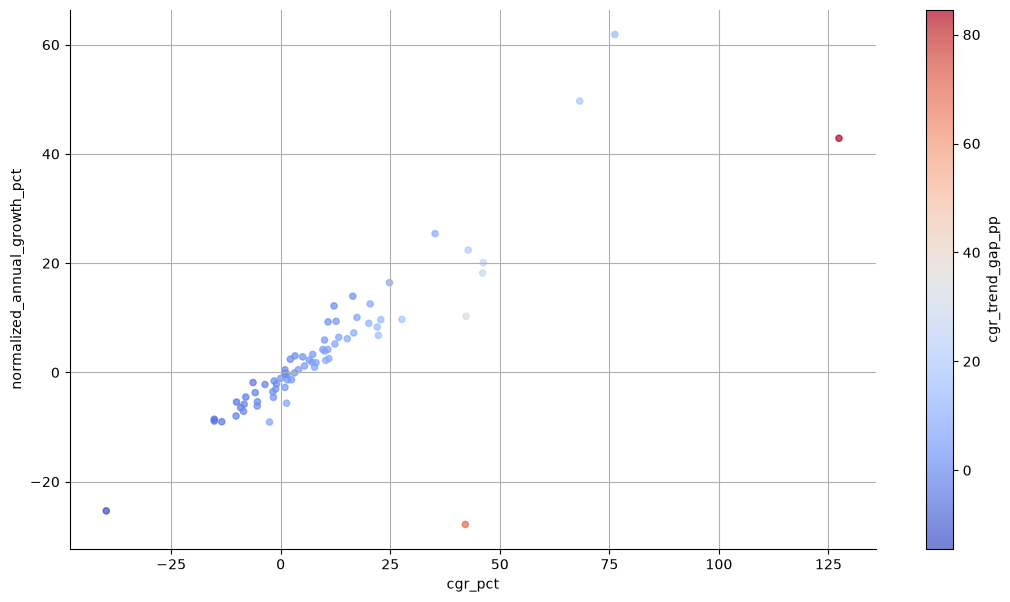

In [17]:
# STEP 06. CGR vs Structural Gap
diagnostic_atc2 = growth_atc2.merge(trend_atc2, on=["group_id", "group_name"], how="left")
diagnostic_atc2["cgr_trend_gap"] = diagnostic_atc2["cgr"] - diagnostic_atc2["normalized_annual_growth"]
diagnostic_atc2["cgr_trend_gap_pp"] = diagnostic_atc2["cgr_trend_gap"] * 100
diagnostic_atc2["gap_robust_z"] = robust_zscore(diagnostic_atc2["cgr_trend_gap_pp"])
diagnostic_atc2["endpoint_distortion_flag"] = (
    diagnostic_atc2["cgr_trend_gap_pp"].abs().ge(GAP_THRESHOLD_PP)
    | diagnostic_atc2["gap_robust_z"].abs().ge(GAP_Z_THRESHOLD)
)
diagnostic_atc2["growth_diagnostic"] = np.select(
    [
        diagnostic_atc2["cgr"].ge(0) & diagnostic_atc2["normalized_annual_growth"].ge(0),
        diagnostic_atc2["cgr"].ge(0) & diagnostic_atc2["normalized_annual_growth"].lt(0),
        diagnostic_atc2["cgr"].lt(0) & diagnostic_atc2["normalized_annual_growth"].ge(0),
        diagnostic_atc2["cgr"].lt(0) & diagnostic_atc2["normalized_annual_growth"].lt(0),
    ],
    ["A: CGR+ / Structural+", "B: CGR+ / Structural-", "C: CGR- / Structural+", "D: CGR- / Structural-"],
    default="Unclassified",
)
print("STEP 06 - CGR and structural growth gap")
display(diagnostic_atc2[["group_id", "cgr_pct", "normalized_annual_growth_pct", "cgr_trend_gap_pp", "endpoint_distortion_flag"]].head())

# diagnostic_atc2.scatter('cgr_pct', 'normalized_annual_growth_pct', c='endpoint_distortion_flag', colormap='coolwarm', alpha=0.7)

diagnostic_atc2.plot(x='cgr_pct', y='normalized_annual_growth_pct', kind='scatter', c='cgr_trend_gap_pp', colormap='coolwarm', alpha=0.7)


In [21]:
# STEP 07. Rolling YoY / Momentum
prior_year_market = monthly_atc2[["group_id", "date", "market_amt"]].copy()
prior_year_market["date"] = prior_year_market["date"] + pd.DateOffset(years=1)
prior_year_market = prior_year_market.rename(columns={"market_amt": "market_amt_prior_year"})
monthly_atc2 = monthly_atc2.merge(prior_year_market, on=["group_id", "date"], how="left")
monthly_atc2["yoy_growth"] =     monthly_atc2["market_amt"] / monthly_atc2["market_amt_prior_year"] - 1

# np.where(
#     monthly_atc2["market_amt_prior_year"] > 0,
#     monthly_atc2["market_amt"] / monthly_atc2["market_amt_prior_year"] - 1,
#     np.nan,
# )
monthly_atc2["yoy_growth_pct"] = monthly_atc2["yoy_growth"] * 100

def calc_yoy_momentum(group: pd.DataFrame) -> pd.Series:
    data = group.dropna(subset=["yoy_growth"]).sort_values("date").copy()
    result = {
        "mean_yoy_growth": data["yoy_growth"].mean(),
        "yoy_growth_sd": data["yoy_growth"].std(),
        "growth_persistence": (data["yoy_growth"] > 0).mean(),
    }
    slope_columns = ("yoy_beta_recent", "yoy_beta_recent_tstat", "yoy_beta_recent_pvalue", "early_yoy_beta", "late_yoy_beta", "yoy_beta_change", "yoy_beta_change_tstat", "yoy_beta_change_pvalue")
    if len(data) < RECENT_YOY_MONTHS:
        return pd.Series(result | {key: np.nan for key in slope_columns})
    recent = data.tail(RECENT_YOY_MONTHS).assign(time=np.arange(RECENT_YOY_MONTHS))
    recent_fit = sm.OLS(recent["yoy_growth"], sm.add_constant(recent["time"])).fit()
    result.update({"yoy_beta_recent": recent_fit.params["time"], "yoy_beta_recent_tstat": recent_fit.tvalues["time"], "yoy_beta_recent_pvalue": recent_fit.pvalues["time"]})
    if len(data) >= 24:
        two_years = data.tail(24).copy().assign(time=np.arange(24))
        two_years["late"] = (two_years["time"] >= 12).astype(int)
        two_years["time_late"] = two_years["time"] * two_years["late"]
        change_fit = sm.OLS(two_years["yoy_growth"], sm.add_constant(two_years[["time", "late", "time_late"]])).fit()
        result.update({"early_yoy_beta": change_fit.params["time"], "late_yoy_beta": change_fit.params["time"] + change_fit.params["time_late"], "yoy_beta_change": change_fit.params["time_late"], "yoy_beta_change_tstat": change_fit.tvalues["time_late"], "yoy_beta_change_pvalue": change_fit.pvalues["time_late"]})
    else:
        result.update({key: np.nan for key in slope_columns[3:]})
    return pd.Series(result)

momentum_atc2 = (monthly_atc2.groupby(["group_id", "group_name"], dropna=False, group_keys=False)
                 .apply(calc_yoy_momentum).reset_index())
diagnostic_atc2 = diagnostic_atc2.merge(momentum_atc2, on=["group_id", "group_name"], how="left")
print("STEP 07 - calendar-aligned YoY momentum")
display(momentum_atc2.head())


STEP 07 - calendar-aligned YoY momentum


,group_id,group_name,mean_yoy_growth,yoy_growth_sd,growth_persistence,yoy_beta_recent,yoy_beta_recent_tstat,yoy_beta_recent_pvalue,early_yoy_beta,late_yoy_beta,yoy_beta_change,yoy_beta_change_tstat,yoy_beta_change_pvalue
0,A01,STOMATOLOGICAL PREPARATIONS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,A02,DRUGS FOR ACID RELATED DISORDERS,0.081337,0.056771,0.916667,0.002245,0.625313,0.545770,-0.002501,0.002245,0.004746,0.734469,0.471188
2,A03,DRUGS FOR FUNCTIONAL GASTROINTESTINAL DISORDERS,0.037222,0.049485,0.833333,0.000576,0.215055,0.834047,-0.001655,0.000576,0.002231,0.362124,0.721058
3,A04,ANTIEMETICS AND ANTINAUSEANTS,-0.001592,0.110613,0.625000,0.009931,1.271741,0.232245,-0.000301,0.009931,0.010232,1.153984,0.262111
4,A05,BILE AND LIVER THERAPY,0.053240,0.076633,0.708333,-0.003846,-1.082657,0.304375,-0.003812,-0.003846,-0.000034,-0.006030,0.995249


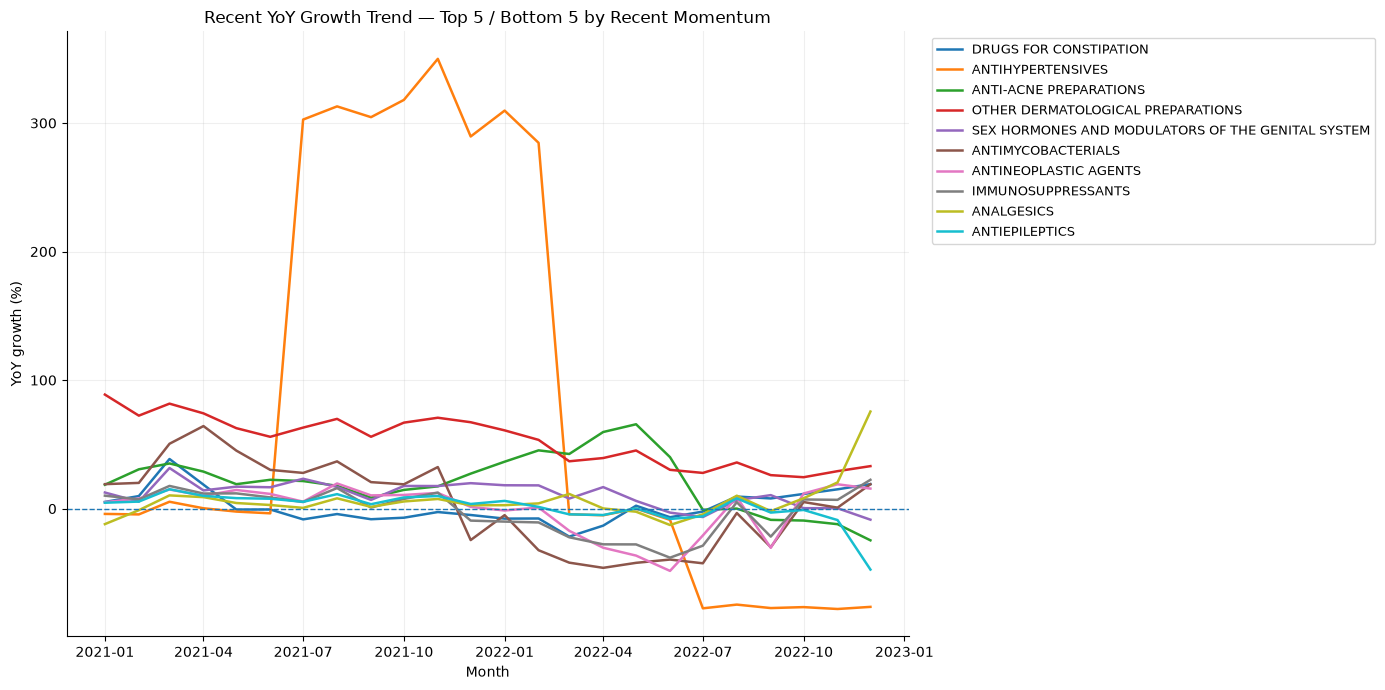

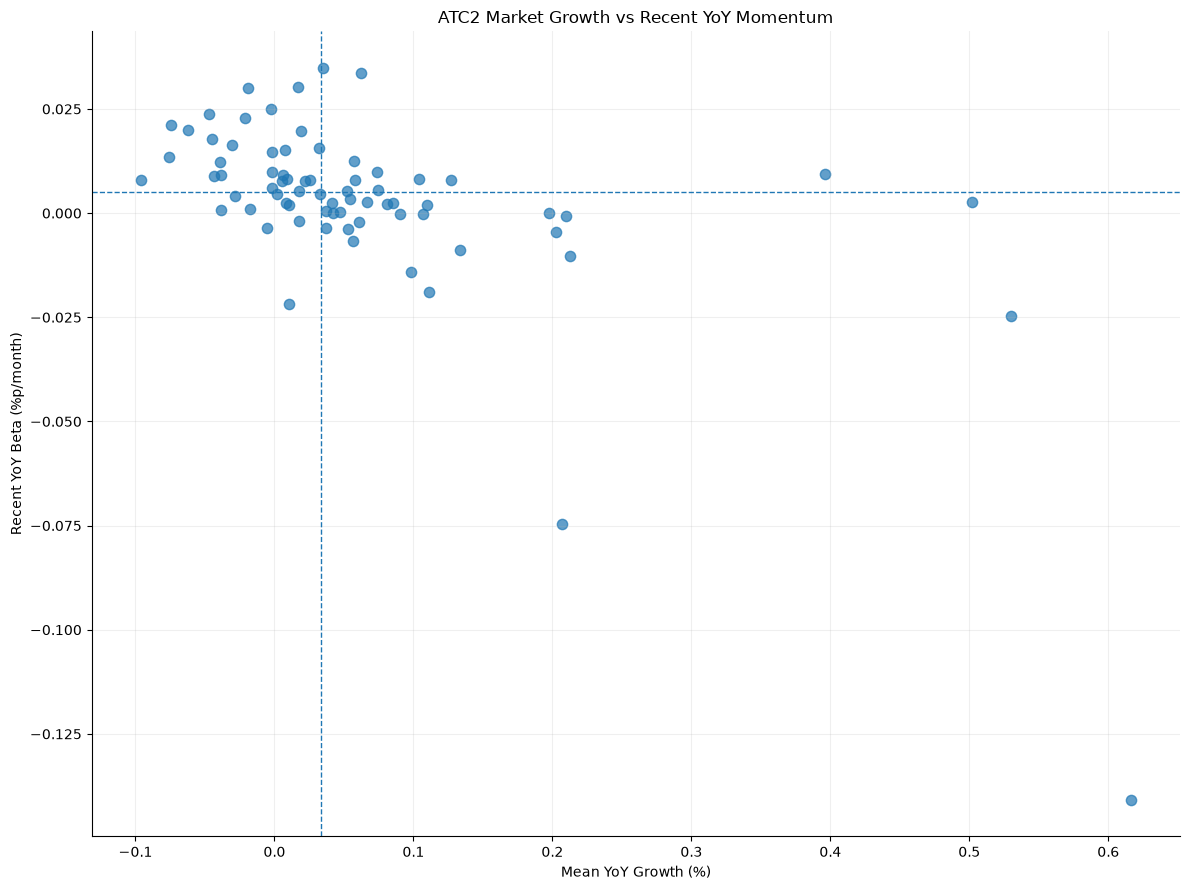

,group_id,group_name,mean_yoy_growth,yoy_beta_recent
41,J04,ANTIMYCOBACTERIALS,0.034632,0.037984
55,N02,ANALGESICS,0.062592,0.033573
5,A06,DRUGS FOR CONSTIPATION,0.017315,0.030191
47,L04,IMMUNOSUPPRESSANTS,-0.019041,0.030060
44,L01,ANTINEOPLASTIC AGENTS,-0.002291,0.025083
42,J05,ANTIVIRALS FOR SYSTEMIC USE,-0.046966,0.023743
46,L03,IMMUNOSTIMULANTS,-0.020851,0.022728
40,J02,ANTIMYCOTICS FOR SYSTEMIC USE,-0.074264,0.021112
16,C01,CARDIAC THERAPY,-0.062463,0.020033
9,A11,VITAMINS,0.019031,0.019608


,group_id,group_name,mean_yoy_growth,yoy_beta_recent
17,C02,ANTIHYPERTENSIVES,0.826787,-0.303153
30,D10,ANTI-ACNE PREPARATIONS,0.206627,-0.074540
31,D11,OTHER DERMATOLOGICAL PREPARATIONS,0.529919,-0.024780
56,N03,ANTIEPILEPTICS,0.010518,-0.021718
34,G03,SEX HORMONES AND MODULATORS OF THE GENITAL SYSTEM,0.110919,-0.018884
70,S01,OPHTHALMOLOGICALS,0.098470,-0.014140
20,C05,VASOPROTECTIVES,0.212783,-0.010231
45,L02,ENDOCRINE THERAPY,0.133861,-0.008735
59,N06,PSYCHOANALEPTICS,0.056200,-0.006742
64,R01,NASAL PREPARATIONS,0.202708,-0.004562


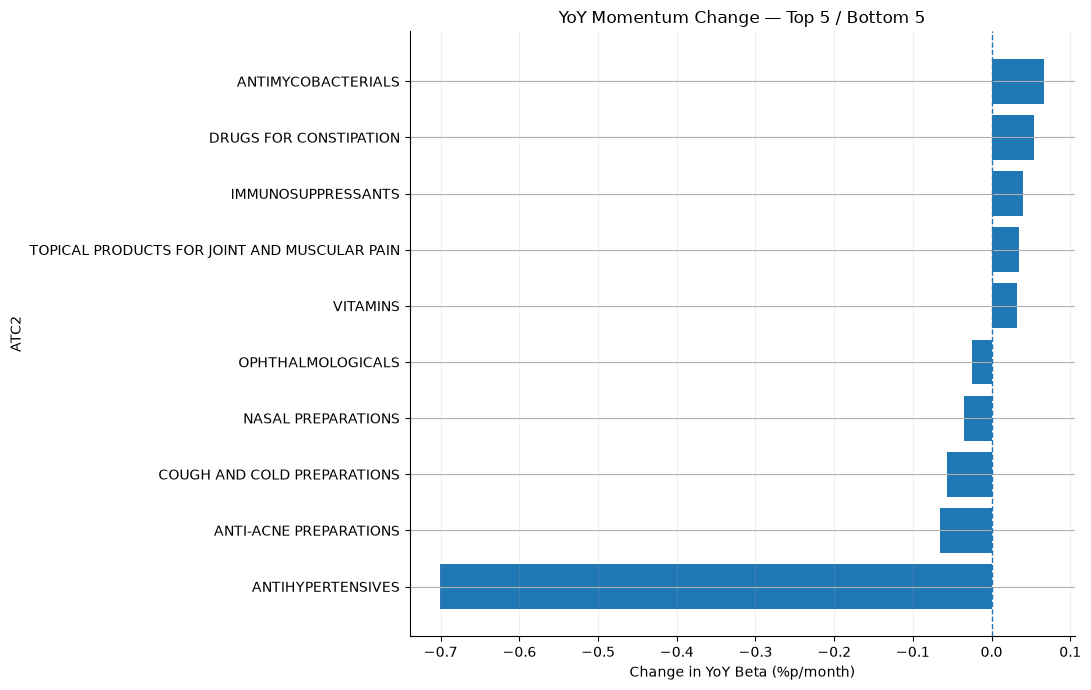

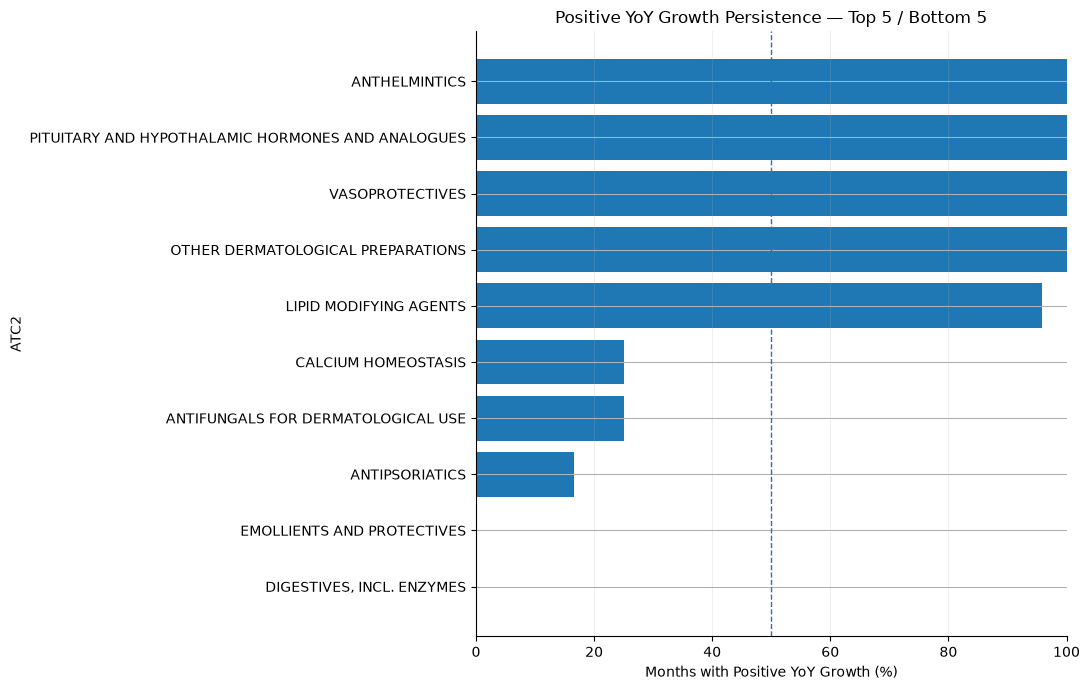

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# STEP 07 Visualization
# - 원본 분석값 유지
# - 시각화에만 1~99 percentile clipping
# - 모든 bar chart = Top 5 / Bottom 5
# ============================================================

viz = momentum_atc2.copy()

# ------------------------------------------------------------
# 0. 숫자형 변환
# ------------------------------------------------------------
metric_cols = [
    "mean_yoy_growth",
    "yoy_beta_recent",
    "yoy_beta_change",
    "growth_persistence",
]

for col in metric_cols:
    viz[col] = pd.to_numeric(viz[col], errors="coerce")


# ============================================================
# Graph 1. Monthly YoY trend
# ============================================================
# 극단적인 antihypertensives 때문에 전체 line chart가 망가지는 것을 방지
# → 모든 ATC2를 그리지 않고 최근 YoY momentum 기준 Top 5 + Bottom 5

selected_groups = (
    viz.dropna(subset=["yoy_beta_recent"])
       .sort_values("yoy_beta_recent")
)

bottom_groups = selected_groups.head(5)["group_id"].tolist()
top_groups = selected_groups.tail(5)["group_id"].tolist()

line_groups = bottom_groups + top_groups

line_df = monthly_atc2[
    monthly_atc2["group_id"].isin(line_groups)
].copy()

line_df["yoy_growth_pct"] = line_df["yoy_growth"] * 100

fig, ax = plt.subplots(figsize=(14, 7))

for group_id, g in line_df.groupby("group_id"):

    g = g.sort_values("date")

    group_name = (
        viz.loc[viz["group_id"] == group_id, "group_name"]
        .iloc[0]
    )

    ax.plot(
        g["date"],
        g["yoy_growth_pct"],
        linewidth=1.8,
        label=group_name
    )

ax.axhline(
    0,
    linewidth=1,
    linestyle="--"
)

ax.set_title(
    "Recent YoY Growth Trend — Top 5 / Bottom 5 by Recent Momentum"
)

ax.set_xlabel("Month")
ax.set_ylabel("YoY growth (%)")

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=9
)

ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()


# ============================================================
# Graph 2. Mean YoY Growth × Recent YoY Beta
# ============================================================
#
# X = 평균 YoY 성장률 (%)
# Y = 최근 YoY beta (%p/month)
#
# beta는 YoY 성장률 그 자체가 아니라
# "YoY 성장률의 월별 변화량"임.
#
# 따라서:
#   X-axis = %
#   Y-axis = %p/month
#
# 시각화에서만 1~99 percentile clipping
# ============================================================

scatter_df = viz.dropna(
    subset=["mean_yoy_growth", "yoy_beta_recent"]
).copy()

# 원본 중앙값
x_median = scatter_df["mean_yoy_growth"].median()
y_median = scatter_df["yoy_beta_recent"].median()

# 시각화용 clipping
x_low, x_high = scatter_df["mean_yoy_growth"].quantile([0.01, 0.99])
y_low, y_high = scatter_df["yoy_beta_recent"].quantile([0.01, 0.99])

scatter_df["x_plot"] = scatter_df["mean_yoy_growth"].clip(
    x_low, x_high
)

scatter_df["y_plot"] = scatter_df["yoy_beta_recent"].clip(
    y_low, y_high
)

fig, ax = plt.subplots(figsize=(12, 9))

ax.scatter(
    scatter_df["x_plot"],
    scatter_df["y_plot"],
    alpha=0.7,
    s=55
)

# 중앙값 기준선
ax.axvline(
    x_median,
    linestyle="--",
    linewidth=1
)

ax.axhline(
    y_median,
    linestyle="--",
    linewidth=1
)

ax.set_title(
    "ATC2 Market Growth vs Recent YoY Momentum"
)

ax.set_xlabel(
    "Mean YoY Growth (%)"
)

ax.set_ylabel(
    "Recent YoY Beta (%p/month)"
)

ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()


# ============================================================
# Graph 2-1. 극단값 확인
# ============================================================
# clipping으로 숨겨진 실제 값 확인용
#
# 특히 antihypertensives가 여기에서 확인될 수 있음.

extreme_check = viz[
    [
        "group_id",
        "group_name",
        "mean_yoy_growth",
        "yoy_beta_recent"
    ]
].copy()

display(
    extreme_check.sort_values(
        "yoy_beta_recent",
        ascending=False
    ).head(10)
)

display(
    extreme_check.sort_values(
        "yoy_beta_recent",
        ascending=True
    ).head(10)
)


# ============================================================
# Graph 3. YoY Beta Change
# ============================================================
# 모든 ATC2를 보여주지 않고
# Top 5 + Bottom 5

beta_change_df = viz.dropna(
    subset=["yoy_beta_change"]
).copy()

top_beta_change = (
    beta_change_df
    .nlargest(5, "yoy_beta_change")
)

bottom_beta_change = (
    beta_change_df
    .nsmallest(5, "yoy_beta_change")
)

beta_change_plot = pd.concat(
    [
        bottom_beta_change,
        top_beta_change
    ]
).drop_duplicates("group_id")

beta_change_plot = beta_change_plot.sort_values(
    "yoy_beta_change"
)

fig, ax = plt.subplots(figsize=(11, 7))

ax.barh(
    beta_change_plot["group_name"],
    beta_change_plot["yoy_beta_change"]
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=1
)

ax.set_title(
    "YoY Momentum Change — Top 5 / Bottom 5"
)

ax.set_xlabel(
    "Change in YoY Beta (%p/month)"
)

ax.set_ylabel(
    "ATC2"
)

ax.grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.show()


# ============================================================
# Graph 4. Growth Persistence
# ============================================================
# Top 5 + Bottom 5

persistence_df = viz.dropna(
    subset=["growth_persistence"]
).copy()

top_persistence = (
    persistence_df
    .nlargest(5, "growth_persistence")
)

bottom_persistence = (
    persistence_df
    .nsmallest(5, "growth_persistence")
)

persistence_plot = pd.concat(
    [
        bottom_persistence,
        top_persistence
    ]
).drop_duplicates("group_id")

persistence_plot = persistence_plot.sort_values(
    "growth_persistence"
)

persistence_plot["persistence_pct"] = (
    persistence_plot["growth_persistence"] * 100
)

fig, ax = plt.subplots(figsize=(11, 7))

ax.barh(
    persistence_plot["group_name"],
    persistence_plot["persistence_pct"]
)

ax.axvline(
    50,
    linestyle="--",
    linewidth=1
)

ax.set_xlim(0, 100)

ax.set_title(
    "Positive YoY Growth Persistence — Top 5 / Bottom 5"
)

ax.set_xlabel(
    "Months with Positive YoY Growth (%)"
)

ax.set_ylabel(
    "ATC2"
)

ax.grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.show()

In [23]:
# STEP 08. Absolute Decline
diagnostic_atc2["is_declining"] = (
    diagnostic_atc2["normalized_annual_growth"].lt(0)
    & diagnostic_atc2["trend_tstat"].abs().ge(DECLINE_TSTAT_THRESHOLD)
)
diagnostic_atc2["decline_severity_rank"] = pd.Series(pd.NA, index=diagnostic_atc2.index, dtype="Int64")
declining_index = diagnostic_atc2.index[diagnostic_atc2["is_declining"]]
diagnostic_atc2.loc[declining_index, "decline_severity_rank"] = (
    diagnostic_atc2.loc[declining_index, "normalized_annual_growth"].rank(ascending=True, method="min").astype("Int64")
)
print("STEP 08 - statistically significant structural decline")
display(diagnostic_atc2.loc[diagnostic_atc2["is_declining"], ["group_id", "group_name", "normalized_annual_growth_pct", "trend_tstat"]])


STEP 08 - statistically significant structural decline


,group_id,group_name,normalized_annual_growth_pct,trend_tstat
16,C01,CARDIAC THERAPY,-9.037130,-4.136374
22,C08,CALCIUM CHANNEL BLOCKERS,-3.703327,-4.957866
25,D01,ANTIFUNGALS FOR DERMATOLOGICAL USE,-5.818384,-7.887353
27,D05,ANTIPSORIATICS,-2.208003,-4.464067
33,G02,OTHER GYNECOLOGICALS,-2.739457,-2.030488
40,J02,ANTIMYCOTICS FOR SYSTEMIC USE,-8.572527,-4.920762
43,J06,IMMUNE SERA AND IMMUNOGLOBULINS,-4.511355,-2.751708
57,N04,ANTI-PARKINSON DRUGS,-8.898730,-4.260561
61,P01,ANTIPROTOZOALS,-6.458067,-3.716096
72,V03,ALL OTHER THERAPEUTIC PRODUCTS,-7.127072,-3.917515


In [25]:
# STEP 09. Matrix A
diagnostic_atc2["log_market_2022"] = np.where(diagnostic_atc2["market_2022"] > 0, np.log(diagnostic_atc2["market_2022"]), np.nan)
diagnostic_atc2["market_size_z"] = robust_zscore(diagnostic_atc2["log_market_2022"])
diagnostic_atc2["structural_growth_z"] = robust_zscore(diagnostic_atc2["trend_beta_monthly"])
diagnostic_atc2["growth_amount_abs_억원"] = diagnostic_atc2["growth_amount_억원"].abs()

def classify_segment(row: pd.Series) -> str | float:
    if pd.isna(row["market_size_z"]) or pd.isna(row["structural_growth_z"]):
        return np.nan
    if row["market_size_z"] >= 0 and row["structural_growth_z"] >= 0:
        return "Star"
    if row["market_size_z"] >= 0:
        return "Cash Cow"
    if row["structural_growth_z"] >= 0:
        return "Rising"
    return "Laggard"

diagnostic_atc2["segment"] = diagnostic_atc2.apply(classify_segment, axis=1)
print("STEP 09 - Matrix A segments")
display(diagnostic_atc2["segment"].value_counts(dropna=False).rename_axis("segment").to_frame("group_count"))


STEP 09 - Matrix A segments


,group_count
segment,
Star,24
Laggard,23
Cash Cow,13
Rising,12
NaN,6


In [27]:
# STEP 10. Matrix B
# Matrix B compares endpoint CGR with structural annual growth.
matrix_b = diagnostic_atc2[["group_id", "group_name", "cgr_pct", "normalized_annual_growth_pct", "cgr_trend_gap_pp", "endpoint_distortion_flag"]].sort_values("cgr_trend_gap_pp", ascending=False)
print("STEP 10 - Matrix B: CGR vs structural annual growth")
display(matrix_b)


STEP 10 - Matrix B: CGR vs structural annual growth


,group_id,group_name,cgr_pct,normalized_annual_growth_pct,cgr_trend_gap_pp,endpoint_distortion_flag
31,D11,OTHER DERMATOLOGICAL PREPARATIONS,127.393991,42.863394,84.530597,True
17,C02,ANTIHYPERTENSIVES,42.136132,-27.835523,69.971655,True
30,D10,ANTI-ACNE PREPARATIONS,42.299063,10.270848,32.028214,True
20,C05,VASOPROTECTIVES,46.080051,18.195074,27.884977,True
36,H01,PITUITARY AND HYPOTHALAMIC HORMONES AND ANALOGUES,46.230235,20.074990,26.155246,True
...,...,...,...,...,...,...
7,A09,"DIGESTIVES, INCL. ENZYMES",NaN,NaN,NaN,False
26,D02,EMOLLIENTS AND PROTECTIVES,NaN,NaN,NaN,False
62,P02,ANTHELMINTICS,53.561372,NaN,NaN,False
63,P03,"ECTOPARASITICIDES, INCL. SCABICIDES, INSECTICI...",NaN,NaN,NaN,False


In [28]:
# STEP 11. Diagnostic Table
DIAGNOSTIC_COLUMNS = [
    "group_id", "group_name", "market_2020", "market_2021", "market_2022", "market_2022_억원", "growth_amount", "growth_amount_억원", "growth_amount_abs_억원",
    "cgr", "cgr_pct", "trend_beta_monthly", "normalized_annual_growth", "normalized_annual_growth_pct", "trend_r2", "trend_tstat", "trend_pvalue",
    "robust_residual_outlier_count", "robust_residual_outlier_rate", "cgr_trend_gap", "cgr_trend_gap_pp", "gap_robust_z", "endpoint_distortion_flag", "growth_diagnostic",
    "mean_yoy_growth", "yoy_growth_sd", "growth_persistence", "yoy_beta_recent", "yoy_beta_recent_tstat", "yoy_beta_recent_pvalue",
    "early_yoy_beta", "late_yoy_beta", "yoy_beta_change", "yoy_beta_change_tstat", "yoy_beta_change_pvalue",
    "is_declining", "decline_severity_rank", "market_size_z", "structural_growth_z", "segment",
]
diagnostic_atc2 = diagnostic_atc2[DIAGNOSTIC_COLUMNS].sort_values(["segment", "growth_amount"], ascending=[True, False], na_position="last").reset_index(drop=True)
print("STEP 11 - complete diagnostic table")
display(diagnostic_atc2)


KeyError: "['mean_yoy_growth', 'yoy_growth_sd', 'growth_persistence', 'yoy_beta_recent', 'yoy_beta_recent_tstat', 'yoy_beta_recent_pvalue', 'early_yoy_beta', 'late_yoy_beta', 'yoy_beta_change', 'yoy_beta_change_tstat', 'yoy_beta_change_pvalue'] not in index"

In [29]:
# STEP 12. Anomaly Groups
# anomaly_groups = {
#     "Star + Declining": diagnostic_atc2.query("segment == 'Star' and is_declining"),
#     "Cash Cow + Declining": diagnostic_atc2.query("segment == 'Cash Cow' and is_declining"),
#     "Rising + Low Reliability": diagnostic_atc2.query("segment == 'Rising' and (abs(trend_tstat) < @DECLINE_TSTAT_THRESHOLD or endpoint_distortion_flag)"),
#     "Laggard + Recovery": diagnostic_atc2.query("segment == 'Laggard' and yoy_beta_recent > 0"),
#     "Endpoint/Structural divergence": diagnostic_atc2.query("abs(cgr_trend_gap_pp) >= @GAP_THRESHOLD_PP or abs(gap_robust_z) >= @GAP_Z_THRESHOLD"),
#     "Negative Growth Amount + CGR": diagnostic_atc2.query("growth_amount < 0 and cgr < 0"),
# }
# for title, frame in anomaly_groups.items():
#     print(f"STEP 12 - {title}: {len(frame)} groups")
#     display(frame)


# %% STEP 12. Data-driven Flag Detection

diagnostic_atc2["flag_structural_decline"] = (
    diagnostic_atc2["normalized_annual_growth"].lt(0)
    & diagnostic_atc2["trend_tstat"].le(-DECLINE_TSTAT_THRESHOLD)
)

diagnostic_atc2["flag_endpoint_structural_divergence"] = (
    diagnostic_atc2["cgr_trend_gap_pp"].abs().ge(GAP_THRESHOLD_PP)
    | diagnostic_atc2["gap_robust_z"].abs().ge(GAP_Z_THRESHOLD)
)

diagnostic_atc2["flag_recent_recovery"] = (
    diagnostic_atc2["normalized_annual_growth"].lt(0)
    & diagnostic_atc2["yoy_beta_recent"].gt(0)
)

diagnostic_atc2["flag_recent_deterioration"] = (
    diagnostic_atc2["normalized_annual_growth"].gt(0)
    & diagnostic_atc2["yoy_beta_recent"].lt(0)
)

diagnostic_atc2["flag_negative_endpoint_growth"] = (
    diagnostic_atc2["growth_amount"].lt(0)
)

diagnostic_atc2["flag_low_trend_reliability"] = (
    diagnostic_atc2["trend_tstat"].abs().lt(DECLINE_TSTAT_THRESHOLD)
)

flag_columns = [
    "flag_structural_decline",
    "flag_endpoint_structural_divergence",
    "flag_recent_recovery",
    "flag_recent_deterioration",
    "flag_negative_endpoint_growth",
    "flag_low_trend_reliability",
]

flag_summary = pd.DataFrame({
    "flag": flag_columns,
    "count": [diagnostic_atc2[c].sum() for c in flag_columns]
})

display(flag_summary)

diagnostic_atc2["is_flagged"] = diagnostic_atc2[flag_columns].any(axis=1)
flagged_targets = diagnostic_atc2[
    diagnostic_atc2["is_flagged"]
].copy()
def get_flag_reasons(row):
    reasons = []

    if row["flag_structural_decline"]:
        reasons.append("Structural decline")

    if row["flag_endpoint_structural_divergence"]:
        reasons.append("CGR-Structural divergence")

    if row["flag_recent_recovery"]:
        reasons.append("Recent recovery")

    if row["flag_recent_deterioration"]:
        reasons.append("Recent deterioration")

    if row["flag_negative_endpoint_growth"]:
        reasons.append("Negative endpoint growth")

    if row["flag_low_trend_reliability"]:
        reasons.append("Low trend reliability")

    return reasons


flagged_targets["flag_reasons"] = flagged_targets.apply(
    get_flag_reasons,
    axis=1
)

display(flagged_targets[["group_id", "group_name", "flag_reasons"]])

KeyError: 'yoy_beta_recent'

In [ ]:
# STEP 13. Segment Summary
segment_summary = (diagnostic_atc2.dropna(subset=["segment"]).groupby("segment", as_index=False)
                   .agg(group_count=("group_id", "size"), total_2022_market=("market_2022", "sum"),
                        total_growth_amount=("growth_amount", "sum"), median_cgr=("cgr", "median"),
                        median_structural_growth=("normalized_annual_growth", "median"), declining_count=("is_declining", "sum")))
segment_summary["group_share"] = segment_summary["group_count"] / segment_summary["group_count"].sum()
segment_summary["declining_share"] = segment_summary["declining_count"] / segment_summary["group_count"]
print("STEP 13 - segment summary")
display(segment_summary)


In [ ]:
# STEP 14. Visualization
plot_names = add_name_label(diagnostic_atc2)
colors = {"Star": "#2E86AB", "Cash Cow": "#F6AE2D", "Rising": "#3DA35D", "Laggard": "#9B59B6"}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
overall_monthly = monthly_atc2.groupby("date", as_index=False)["market_amt_억원"].sum()
axes[0, 0].plot(overall_monthly["date"], overall_monthly["market_amt_억원"], linewidth=2)
axes[0, 0].set(title="Figure 1 - ATC2 Total Monthly Market Size", xlabel="Month", ylabel="Market Size (억원)")
axes[0, 1].hist(diagnostic_atc2["normalized_annual_growth_pct"].dropna(), bins=20, edgecolor="white")
axes[0, 1].set(title="Figure 2 - Structural Annual Growth Distribution", xlabel="Growth (%)", ylabel="ATC2 count")
for segment, frame in diagnostic_atc2.groupby("segment", dropna=True):
    for is_positive, marker in ((True, "^"), (False, "v")):
        points = frame[frame["growth_amount"].ge(0) == is_positive]
        axes[1, 0].scatter(points["market_size_2022_억원"], points["normalized_annual_growth_pct"],
                            s=np.sqrt(points["growth_amount_abs_억원"].fillna(0)) * 30 + 30,
                            marker=marker, c=colors[segment], alpha=.7, label=segment if is_positive else None, edgecolors="white")
axes[1, 0].axvline(diagnostic_atc2["market_size_2022_억원"].median(), color="grey", linestyle="--")
axes[1, 0].axhline(diagnostic_atc2["normalized_annual_growth_pct"].median(), color="grey", linestyle="--")
axes[1, 0].set_xscale("log")
axes[1, 0].set(title="Figure 3 - Matrix A", xlabel="2022 Market Size (억원, log)", ylabel="Structural Growth (%)")
axes[1, 0].legend(fontsize=8)
axes[1, 1].scatter(diagnostic_atc2["cgr_pct"], diagnostic_atc2["normalized_annual_growth_pct"], alpha=.7)
finite_values = diagnostic_atc2[["cgr_pct", "normalized_annual_growth_pct"]].stack().dropna()
axes[1, 1].plot([finite_values.min(), finite_values.max()], [finite_values.min(), finite_values.max()], "k--")
flag = diagnostic_atc2[diagnostic_atc2["endpoint_distortion_flag"]]
axes[1, 1].scatter(flag["cgr_pct"], flag["normalized_annual_growth_pct"], facecolors="none", edgecolors="red", s=100)
axes[1, 1].set(title="Figure 4 - Matrix B", xlabel="CGR (%)", ylabel="Structural Growth (%)")
plt.tight_layout()
plt.show()

flagged_ids = diagnostic_atc2.loc[diagnostic_atc2["is_declining"] | diagnostic_atc2["endpoint_distortion_flag"], "group_id"].head(TOP_N_GROUPS)
flagged_monthly = monthly_atc2[monthly_atc2["group_id"].isin(flagged_ids)]
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for group_id, frame in flagged_monthly.groupby("group_id"):
    axes[0].plot(frame["date"], frame["market_amt_억원"], label=add_name_label(frame).iloc[0])
axes[0].set(title="Figure 5 - Flagged Monthly Paths", xlabel="Month", ylabel="억원")
if not flagged_monthly.empty:
    axes[0].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7)
axes[1].hist(diagnostic_atc2["cgr_trend_gap_pp"].dropna(), bins=20, edgecolor="white")
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set(title="Figure 6 - CGR minus Structural Growth", xlabel="Percentage points", ylabel="ATC2 count")
momentum_rank = diagnostic_atc2.dropna(subset=["yoy_beta_recent"]).sort_values("yoy_beta_recent")
plot_momentum = pd.concat([momentum_rank.head(TOP_N_GROUPS), momentum_rank.tail(TOP_N_GROUPS)]).drop_duplicates("group_id")
axes[2].barh(add_name_label(plot_momentum), plot_momentum["yoy_beta_recent"] * 100)
axes[2].set(title="Figure 7 - Recent YoY Momentum", xlabel="Slope (pp/month)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 6))
plt.scatter(diagnostic_atc2["yoy_beta_recent"] * 100, diagnostic_atc2["normalized_annual_growth_pct"], alpha=.7)
plt.title("Figure 8 - Momentum x Structural Growth")
plt.xlabel("Recent YoY slope (pp/month)")
plt.ylabel("Structural Annual Growth (%)")
plt.tight_layout()
plt.show()


In [ ]:
# STEP 15. Final QA
final_qa = pd.DataFrame([{
    "ATC2 group count": diagnostic_atc2["group_id"].nunique(),
    "ATC2 source/panel counts agree": diagnostic_atc2["group_id"].nunique() == int(source_qa.loc[0, "analysis_distinct_atc2"]),
    "36 months": monthly_atc2["date"].nunique() == ANALYSIS_MONTHS,
    "ATC2 monthly observations min": atc2_month_qa["month_observations"].min(),
    "ATC2 monthly observations max": atc2_month_qa["month_observations"].max(),
    "all ATC2 have 36 months": atc2_month_qa["month_observations"].eq(ANALYSIS_MONTHS).all(),
    "missing group_name count": diagnostic_atc2["group_name"].isna().sum(),
    "missing group_name from master count": monthly_atc2.loc[monthly_atc2["group_name_missing_from_master"], "group_id"].nunique(),
    "missing market amount count": monthly_atc2["market_amt"].isna().sum(),
    "missing trend result count": diagnostic_atc2["normalized_annual_growth"].isna().sum(),
    "missing CGR count": diagnostic_atc2["cgr"].isna().sum(),
    "declining group count": diagnostic_atc2["is_declining"].sum(),
    "segment group count": diagnostic_atc2["segment"].notna().sum(),
    "segment sum equals ATC2 count": diagnostic_atc2["segment"].notna().sum() == diagnostic_atc2["group_id"].nunique(),
    "declining groups have segments": diagnostic_atc2.loc[diagnostic_atc2["is_declining"], "segment"].notna().all(),
}])
print("STEP 15 - final QA")
display(final_qa)
assert bool(final_qa.loc[0, "36 months"])
assert bool(final_qa.loc[0, "ATC2 source/panel counts agree"])
assert bool(final_qa.loc[0, "segment sum equals ATC2 count"])
assert bool(final_qa.loc[0, "declining groups have segments"])
con.close()
